## Pre-processing
-  Images resized to 224×224 <br>
-  Normalized pixel values to [0,1] <br>
-  Stratified train-validation split <br>
-  Applied data augmentation to improve generalization

### Libraries

In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Loading Dataset

In [20]:
DATA_DIR = r"C:\Users\dell\Brain-Tumor-Localization-from-MRI-with-Explainable-AI\data\raw"
IMG_SIZE = 224

### Loading + Pre-processing Data

In [21]:
images = []
labels = []

for label in ["yes", "no"]:
    path = os.path.join(DATA_DIR, label)
    class_num = 1 if label == "yes" else 0

    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # better for display
            img = img / 255.0  # normalize

            images.append(img)
            labels.append(class_num)

        except Exception as e:
            print(f"Error: {img_name}")

### Conversion to Numpy

In [22]:
X = np.array(images)
y = np.array(labels)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

Images shape: (253, 224, 224, 3)
Labels shape: (253,)


### Data Distribution

In [23]:
print("Tumor (1):", sum(y))
print("No Tumor (0):", len(y) - sum(y))

Tumor (1): 155
No Tumor (0): 98


### Pre-processed Sample Images

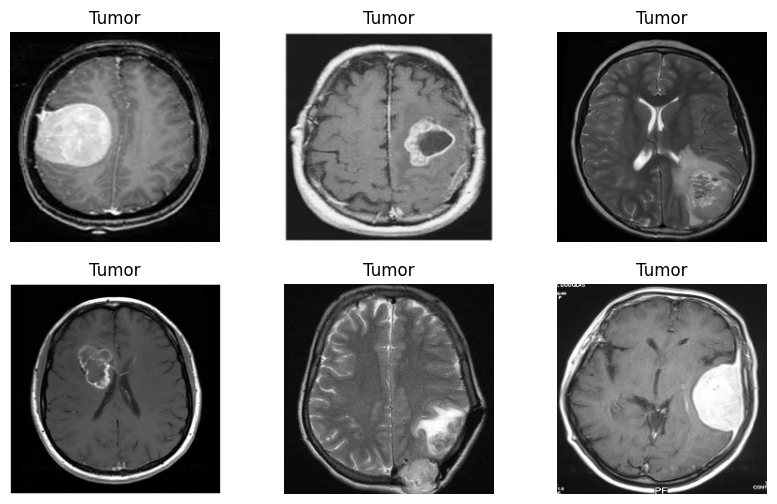

In [24]:
plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X[i])
    plt.title("Tumor" if y[i] == 1 else "No Tumor")
    plt.axis("off")

plt.show()

### Train/Validation Split

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (202, 224, 224, 3)
Validation shape: (51, 224, 224, 3)


### Data Augmentation

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

### Augmentation Visualization

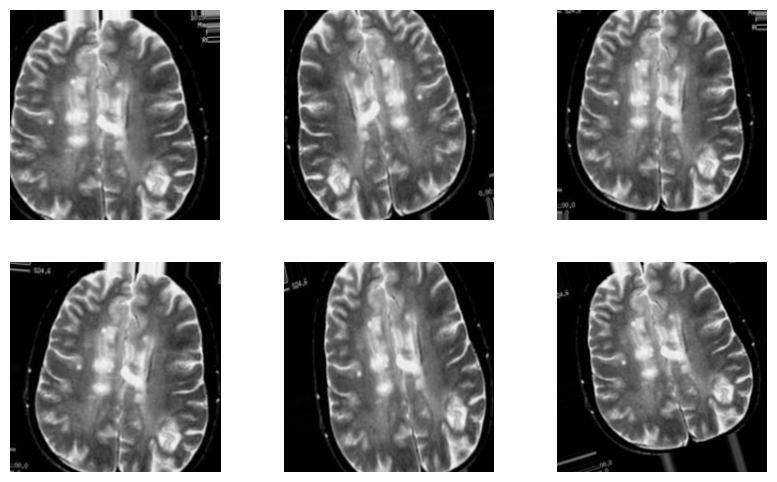

In [30]:
sample_img = X_train[0]

sample_img = sample_img.reshape((1, *sample_img.shape))

plt.figure(figsize=(10,6))

i = 0
for batch in datagen.flow(sample_img, batch_size=1):
    plt.subplot(2,3,i+1)
    plt.imshow(batch[0])
    plt.axis("off")
    i += 1
    if i >= 6:
        break

plt.show()

In [1]:
!git commit -m "Modified and added notes on pre-processing"

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   preprocessing.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../.ipynb_checkpoints/pull-checkpoint.ipynb
	../pull.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
